# EDA: Gender Prediction
DME-Encoder project — exploratory data analysis for the gender dataset.

In [1]:
# Cell 1 — README и описание
from pathlib import Path
from IPython.display import Markdown, display

readme_text = Path("../data/raw/gender/README.md").read_text()
display(Markdown(readme_text))
print(readme_text)

---
pretty_name: Prediction of client gender on card transactions
configs:
- config_name: transactions_data
  data_files: transactions.csv.gz
- config_name: labels
  data_files: gender_train.csv
task_categories:
- tabular-classification
tags:
- finance
---

https://www.kaggle.com/c/python-and-analyze-data-final-project/

---
pretty_name: Prediction of client gender on card transactions
configs:
- config_name: transactions_data
  data_files: transactions.csv.gz
- config_name: labels
  data_files: gender_train.csv
task_categories:
- tabular-classification
tags:
- finance
---

https://www.kaggle.com/c/python-and-analyze-data-final-project/


In [2]:
# Cell 2 — Загрузка всех файлов
import pandas as pd
import numpy as np
import os

os.makedirs("../outputs/figures/eda", exist_ok=True)
os.makedirs("../outputs/metrics", exist_ok=True)

# Загрузка
txn       = pd.read_csv("../data/raw/gender/transactions.csv.gz")
labels    = pd.read_csv("../data/raw/gender/gender_train.csv")
subm      = pd.read_csv("../data/raw/gender/gender_test_kaggle_sample_submission.csv")
mcc_ref   = pd.read_csv("../data/raw/gender/tr_mcc_codes.csv", sep=";")
type_ref  = pd.read_csv("../data/raw/gender/tr_types.csv", sep=";")

for name, df in [("transactions", txn), ("gender_train", labels),
                 ("submission", subm), ("tr_mcc_codes", mcc_ref), ("tr_types", type_ref)]:
    print(f"\n=== {name} ===")
    print(f"Shape: {df.shape}")
    display(df.head(3))

# Парсинг tr_datetime: формат "D HH:MM:SS" → total_seconds (целое число)
def parse_rel_datetime(series):
    """'0 10:23:26' → абсолютный Timestamp (epoch = 2010-01-01)"""
    parts = series.str.split(" ", n=1, expand=True)
    days  = pd.to_numeric(parts[0], errors="coerce")
    times = pd.to_timedelta(parts[1], errors="coerce")
    epoch = pd.Timestamp("2010-01-01")
    return epoch + pd.to_timedelta(days, unit="D") + times

txn["timestamp"] = parse_rel_datetime(txn["tr_datetime"])

# Merge transactions + labels (left join — test-клиенты останутся с NaN gender)
txn = txn.merge(labels, on="customer_id", how="left")

print("\n=== transactions (после merge) ===")
print(f"Shape: {txn.shape}")
display(txn.head(3))
print("\nDtypes:")
print(txn.dtypes)

# Определение ролей
ENTITY_COL     = "customer_id"
TIMESTAMP_COL  = "timestamp"
EVENT_TYPE_COL = "mcc_code"   # основной event_type: 4-значные MCC-коды
TARGET_COL     = "gender"
NUM_COLS       = ["amount"]
CAT_COLS       = ["tr_type"]  # term_id почти пустой — исключаем

print("\n=== Маппинг колонок ===")
role_map = [
    ("customer_id",  "entity_id",         txn["customer_id"].dtype),
    ("tr_datetime",  "timestamp (raw)",   txn["tr_datetime"].dtype),
    ("timestamp",    "timestamp (parsed)",txn["timestamp"].dtype),
    ("mcc_code",     "event_type",         txn["mcc_code"].dtype),
    ("tr_type",      "categorical",        txn["tr_type"].dtype),
    ("amount",       "numerical",          txn["amount"].dtype),
    ("term_id",      "sparse cat (aux)",  txn["term_id"].dtype),
    ("gender",       "target",             txn["gender"].dtype),
]
display(pd.DataFrame(role_map, columns=["column", "role", "dtype"]))

print("\nЗамечание: mcc_code — основной event_type; tr_type — дополнительный категориальный признак.")
print("tr_mcc_codes и tr_types — справочники, НЕ джойнятся в датасет, используются только для интерпретации.")


=== transactions ===
Shape: (6849346, 6)


,customer_id,tr_datetime,mcc_code,tr_type,amount,term_id
0,39026145,0 10:23:26,4814,1030,-2245.92,NaN
1,39026145,1 10:19:29,6011,7010,56147.89,NaN
2,39026145,1 10:20:56,4829,2330,-56147.89,NaN



=== gender_train ===
Shape: (8400, 2)


,customer_id,gender
0,10928546,1
1,69348468,1
2,61009479,0



=== submission ===
Shape: (3600, 2)


...


=== transactions (после merge) ===
Shape: (6849346, 8)


,customer_id,tr_datetime,mcc_code,tr_type,amount,term_id,timestamp,gender
0,39026145,0 10:23:26,4814,1030,-2245.92,NaN,2010-01-01 10:23:26,1.0
1,39026145,1 10:19:29,6011,7010,56147.89,NaN,2010-01-02 10:19:29,1.0
2,39026145,1 10:20:56,4829,2330,-56147.89,NaN,2010-01-02 10:20:56,1.0



Dtypes:
customer_id             int64
tr_datetime            object
mcc_code                int64
tr_type                 int64
amount                float64
term_id                object
timestamp      datetime64[ns]
gender                float64
dtype: object

=== Маппинг колонок ===


,column,role,dtype
0,customer_id,entity_id,int64
1,tr_datetime,timestamp (raw),object
2,timestamp,timestamp (parsed),datetime64[ns]
3,mcc_code,event_type,int64
4,tr_type,categorical,int64
5,amount,numerical,float64
6,term_id,sparse cat (aux),object
7,gender,target,float64



Замечание: mcc_code — основной event_type; tr_type — дополнительный категориальный признак.
tr_mcc_codes и tr_types — справочники, НЕ джойнятся в датасет, используются только для интерпретации.


Клиентов с меткой (train):   8,400
Клиентов без метки (test):   3,600
Клиентов в transactions:     15,000

Распределение длин последовательностей:
mean        456.6
median      324.5
p75         565.0
p90         858.0
p95        1089.1
p99        1929.1
max       88781.0

Клиентов с < 5 транзакций: 42 (0.3%)
Рекомендуемый max_seq_len (p95): 1089


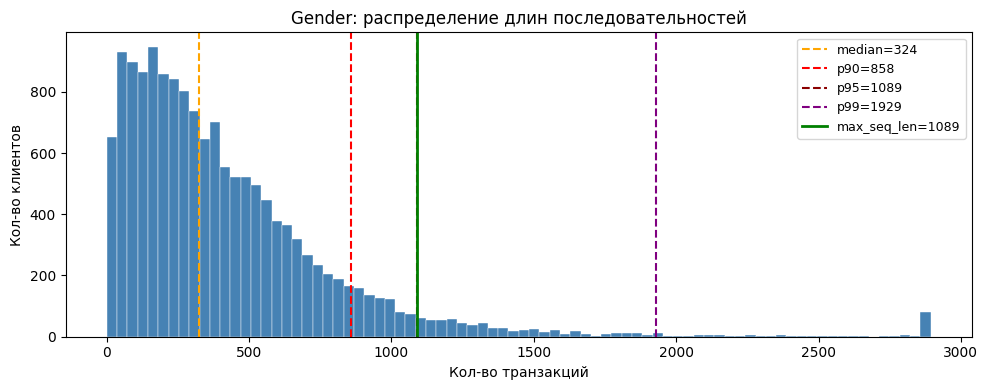

Сохранено: outputs/figures/eda/gender_seq_length.png


In [3]:
# Cell 3 — Статистика по клиентам
import matplotlib.pyplot as plt

train_ids  = set(labels["customer_id"].unique())
test_ids   = set(subm["customer_id"].unique())
all_ids    = set(txn["customer_id"].unique())

print(f"Клиентов с меткой (train):   {len(train_ids):,}")
print(f"Клиентов без метки (test):   {len(test_ids):,}")
print(f"Клиентов в transactions:     {len(all_ids):,}")

txn_counts = txn.groupby(ENTITY_COL).size()
pcts = txn_counts.quantile([0.50, 0.75, 0.90, 0.95, 0.99])

print("\nРаспределение длин последовательностей:")
stats = pd.Series({
    "mean":   txn_counts.mean(),
    "median": txn_counts.median(),
    "p75":    pcts[0.75],
    "p90":    pcts[0.90],
    "p95":    pcts[0.95],
    "p99":    pcts[0.99],
    "max":    txn_counts.max(),
})
print(stats.round(1).to_string())

lt5 = (txn_counts < 5).sum()
print(f"\nКлиентов с < 5 транзакций: {lt5:,} ({100*lt5/len(txn_counts):.1f}%)")

recommended_max = int(pcts[0.95])
print(f"Рекомендуемый max_seq_len (p95): {recommended_max}")

# График
fig, ax = plt.subplots(figsize=(10, 4))
clip_val = int(pcts[0.99]) * 1.5
ax.hist(txn_counts.clip(upper=clip_val), bins=80, color="steelblue",
        edgecolor="white", linewidth=0.3)
line_styles = {"median": ("orange", "--"), "p90": ("red", "--"),
               "p95": ("darkred", "--"), "p99": ("purple", "--")}
for label, pct in [("median", 0.50), ("p90", 0.90), ("p95", 0.95), ("p99", 0.99)]:
    v = pcts[pct]
    c, ls = line_styles[label]
    ax.axvline(v, color=c, linestyle=ls, linewidth=1.5, label=f"{label}={v:.0f}")
ax.axvline(recommended_max, color="green", linestyle="-", linewidth=2,
           label=f"max_seq_len={recommended_max}")
ax.set_xlabel("Кол-во транзакций")
ax.set_ylabel("Кол-во клиентов")
ax.set_title("Gender: распределение длин последовательностей")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/figures/eda/gender_seq_length.png", dpi=150)
plt.show()
print("Сохранено: outputs/figures/eda/gender_seq_length.png")

Клиентов с меткой:    8,400
Клиентов без метки:   6,600 (test set)

Распределение gender (по клиентам):


,count,%
gender,,
0 (female),4687,55.8
1 (male),3713,44.2



Коэффициент дисбаланса: 1.262
Рекомендация: классы почти сбалансированы, class_weights опциональны


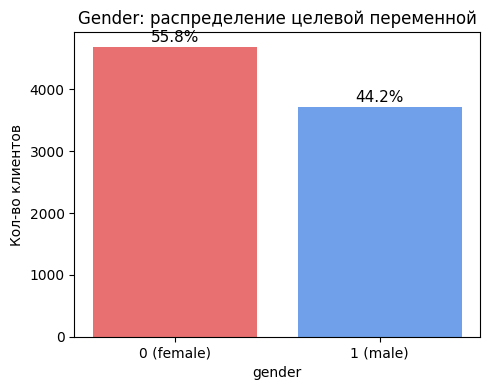

Сохранено: outputs/figures/eda/gender_target.png


In [4]:
# Cell 4 — Целевая переменная (gender)
client_gender = txn.groupby(ENTITY_COL)[TARGET_COL].first()

labeled   = client_gender.dropna()
unlabeled = client_gender[client_gender.isna()]

print(f"Клиентов с меткой:    {len(labeled):,}")
print(f"Клиентов без метки:   {len(unlabeled):,} (test set)")

vc = labeled.value_counts().sort_index()
vc_pct = vc / vc.sum() * 100
tdf = pd.DataFrame({"count": vc, "%": vc_pct.round(2)})
tdf.index = tdf.index.map({0: "0 (female)", 1: "1 (male)"})
print("\nРаспределение gender (по клиентам):")
display(tdf)

imbalance = vc.max() / vc.min()
print(f"\nКоэффициент дисбаланса: {imbalance:.3f}")
if imbalance > 1.5:
    print("Рекомендация: использовать class_weights или oversampling")
else:
    print("Рекомендация: классы почти сбалансированы, class_weights опциональны")

# График
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["0 (female)", "1 (male)"], vc.values, color=["#e97070", "#70a0e9"])
for bar, pct in zip(bars, vc_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=11)
ax.set_xlabel("gender")
ax.set_ylabel("Кол-во клиентов")
ax.set_title("Gender: распределение целевой переменной")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/gender_target.png", dpi=150)
plt.show()
print("Сохранено: outputs/figures/eda/gender_target.png")

Уникальных MCC кодов: 184

Топ-30 MCC кодов (с описанием):


,count,%,description
mcc_code,,,
6011,1447370,21.132,Финансовые институты — снятие наличности автом...
6010,1021046,14.907,Финансовые институты — снятие наличности вручную
4814,987181,14.413,"Звонки с использованием телефонов, считывающих..."
5411,961860,14.043,"Бакалейные магазины, супермаркеты"
4829,624643,9.120,Денежные переводы
5499,336014,4.906,"Различные продовольственные магазины — рынки, ..."
5541,141825,2.071,Станции техобслуживания
5912,134031,1.957,Аптеки
5331,127890,1.867,Универсальные магазины



Редких MCC (count <  5): 0
Редких MCC (count < 10): 0
Доля топ-10 MCC в объёме: 86.0%


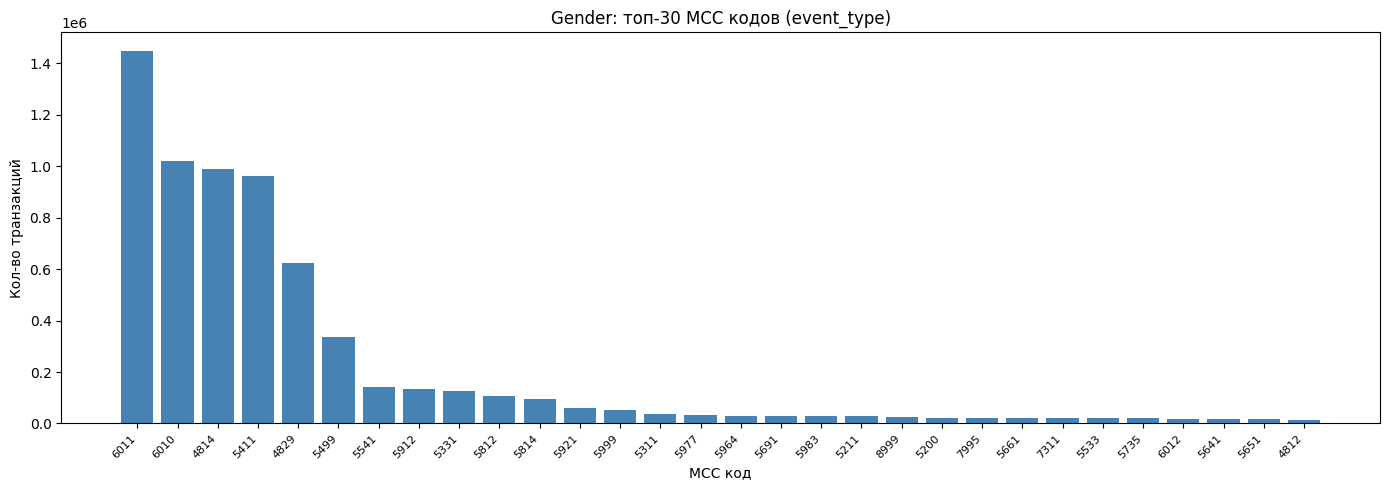

Сохранено: outputs/figures/eda/gender_mcc_freq.png


In [5]:
# Cell 5 — Анализ MCC кодов как event_type
n_unique_mcc = txn[EVENT_TYPE_COL].nunique()
total_txn    = len(txn)

print(f"Уникальных MCC кодов: {n_unique_mcc}")

mcc_counts = txn[EVENT_TYPE_COL].value_counts()
top30 = mcc_counts.head(30)

# Обогащение описаниями из справочника
mcc_ref_idx = mcc_ref.set_index("mcc_code")["mcc_description"]
top30_df = pd.DataFrame({"count": top30, "%": (top30 / total_txn * 100).round(3)})
top30_df["description"] = top30_df.index.map(mcc_ref_idx).fillna("—")
print("\nТоп-30 MCC кодов (с описанием):")
display(top30_df)

rare_lt5  = (mcc_counts < 5).sum()
rare_lt10 = (mcc_counts < 10).sum()
top10_share = mcc_counts.head(10).sum() / total_txn * 100
print(f"\nРедких MCC (count <  5): {rare_lt5}")
print(f"Редких MCC (count < 10): {rare_lt10}")
print(f"Доля топ-10 MCC в объёме: {top10_share:.1f}%")

# График
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(top30)), top30.values, color="steelblue")
ax.set_xticks(range(len(top30)))
ax.set_xticklabels([str(x) for x in top30.index], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("MCC код")
ax.set_ylabel("Кол-во транзакций")
ax.set_title("Gender: топ-30 MCC кодов (event_type)")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/gender_mcc_freq.png", dpi=150)
plt.show()
print("Сохранено: outputs/figures/eda/gender_mcc_freq.png")

In [6]:
# Cell 6 — Анализ типов транзакций (tr_type)
print("=== Колонка tr_type ===")
n_unique_type = txn["tr_type"].nunique()
print(f"Уникальных tr_type: {n_unique_type}")

# Обогащение описаниями
type_ref_idx = type_ref.set_index("tr_type")["tr_description"]
type_counts  = txn["tr_type"].value_counts()
top20_types  = type_counts.head(20)
top20_df = pd.DataFrame({"count": top20_types, "%": (top20_types / total_txn * 100).round(3)})
top20_df["description"] = top20_df.index.map(type_ref_idx).fillna("—")
print("\nТоп-20 tr_type (с описанием):")
display(top20_df)

# Взаимосвязь MCC и tr_type
print("\nВзаимосвязь MCC × tr_type (топ-10 MCC, топ-5 tr_type каждого):")
top10_mcc = mcc_counts.head(10).index.tolist()
cross = txn[txn[EVENT_TYPE_COL].isin(top10_mcc)].groupby(
    [EVENT_TYPE_COL, "tr_type"]).size().reset_index(name="count")
cross_top = cross.sort_values([EVENT_TYPE_COL, "count"], ascending=[True, False])
cross_top = cross_top.groupby(EVENT_TYPE_COL).head(3)
cross_top["mcc_desc"]  = cross_top[EVENT_TYPE_COL].map(mcc_ref_idx).fillna("—")
cross_top["type_desc"] = cross_top["tr_type"].map(type_ref_idx).fillna("—")
display(cross_top.reset_index(drop=True))

# tr_type как CAT_COL: мощность и словарь
print(f"\nМощность словаря tr_type: {n_unique_type}")
rare_types = (type_counts < 5).sum()
print(f"Редких tr_type (count < 5): {rare_types}")

=== Колонка tr_type ===
Уникальных tr_type: 77

Топ-20 tr_type (с описанием):


,count,%,description
tr_type,,,
1010,1589734,23.210,Покупка. POS ТУ СБ РФ
2010,1040713,15.194,Выдача наличных в АТМ Сбербанк России
1030,970994,14.176,Оплата услуги. Банкоматы СБ РФ
1110,928154,13.551,Покупка. POS ТУ Россия
7070,691896,10.102,Перевод на карту (с карты) через Мобильный бан...
2370,376521,5.497,Списание с карты на карту по операции <перевод...
7010,258088,3.768,Взнос наличных через АТМ (в своем тер.банке)
7030,155200,2.266,Перевод на карту (с карты) через АТМ (в предел...
1100,117870,1.721,Покупка. ТУ Россия



Взаимосвязь MCC × tr_type (топ-10 MCC, топ-5 tr_type каждого):


,mcc_code,tr_type,count,mcc_desc,type_desc
0,4814,1030,970799,"Звонки с использованием телефонов, считывающих...",Оплата услуги. Банкоматы СБ РФ
1,4814,1100,14257,"Звонки с использованием телефонов, считывающих...",Покупка. ТУ Россия
2,4814,1010,1028,"Звонки с использованием телефонов, считывающих...",Покупка. POS ТУ СБ РФ
3,4829,2370,376521,Денежные переводы,Списание с карты на карту по операции <перевод...
4,4829,2330,69633,Денежные переводы,Списание с карты по операции “перевода с карты...
5,4829,2371,65809,Денежные переводы,Списание с карты на карту по операции <перевод...
6,5331,1010,122313,Универсальные магазины,Покупка. POS ТУ СБ РФ
7,5331,1110,4097,Универсальные магазины,Покупка. POS ТУ Россия
8,5331,1100,722,Универсальные магазины,Покупка. ТУ Россия
9,5411,1010,567734,"Бакалейные магазины, супермаркеты",Покупка. POS ТУ СБ РФ



Мощность словаря tr_type: 77
Редких tr_type (count < 5): 3


Статистика time_delta (секунды):
mean         80901.6
median       16626.0
p75          79785.0
p90         184646.0
p99         950258.1
max       31074827.0

Доля нулевых дельт:       4.09%
Доля отрицательных дельт: 0.00%



Mean/Median ratio: 4.9x — heavy tail → рекомендован log1p


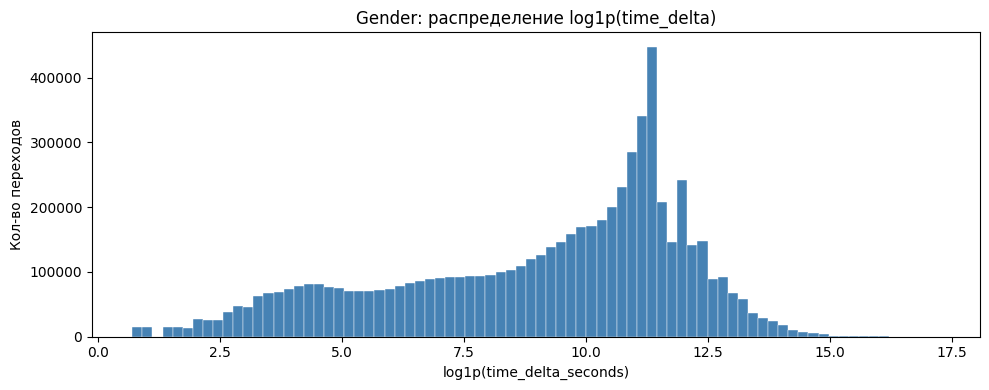

Сохранено: outputs/figures/eda/gender_time_delta.png


In [7]:
# Cell 7 — Анализ time_delta
txn_sorted = txn.sort_values([ENTITY_COL, TIMESTAMP_COL])
td_sec = (
    txn_sorted
    .groupby(ENTITY_COL)[TIMESTAMP_COL]
    .diff()
    .dt.total_seconds()
)

td_valid = td_sec.dropna()
pct_td   = td_valid.quantile([0.50, 0.75, 0.90, 0.99])

print("Статистика time_delta (секунды):")
stats_td = pd.Series({
    "mean":   td_valid.mean(),
    "median": td_valid.median(),
    "p75":    pct_td[0.75],
    "p90":    pct_td[0.90],
    "p99":    pct_td[0.99],
    "max":    td_valid.max(),
})
print(stats_td.round(1).to_string())

zero_frac = (td_valid == 0).mean() * 100
neg_frac  = (td_valid < 0).mean() * 100
print(f"\nДоля нулевых дельт:       {zero_frac:.2f}%")
print(f"Доля отрицательных дельт: {neg_frac:.2f}%")

mean_v, median_v = td_valid.mean(), td_valid.median()
print(f"\nMean/Median ratio: {mean_v/max(median_v,1):.1f}x — ", end="")
if mean_v > 3 * median_v:
    print("heavy tail → рекомендован log1p")
else:
    print("умеренное распределение")

# График
td_pos = td_valid[td_valid > 0]
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.log1p(td_pos), bins=80, color="steelblue", edgecolor="white", linewidth=0.3)
ax.set_xlabel("log1p(time_delta_seconds)")
ax.set_ylabel("Кол-во переходов")
ax.set_title("Gender: распределение log1p(time_delta)")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/gender_time_delta.png", dpi=150)
plt.show()
print("Сохранено: outputs/figures/eda/gender_time_delta.png")

In [8]:
# Cell 8 — Анализ числовых признаков (amount)
print("=== amount ===")
s = txn["amount"]

pct99     = s.quantile(0.99)
pct_null  = s.isna().mean() * 100
pct_zero  = (s == 0).mean() * 100
pct_neg   = (s < 0).mean() * 100
skewness  = s.dropna().skew()

print(f"mean:      {s.mean():.2f}")
print(f"std:       {s.std():.2f}")
print(f"min:       {s.min():.2f}")
print(f"max:       {s.max():.2f}")
print(f"p99:       {pct99:.2f}")
print(f"% null:    {pct_null:.2f}%")
print(f"% zero:    {pct_zero:.2f}%")
print(f"% neg:     {pct_neg:.2f}%")
print(f"skewness:  {skewness:.2f}")

if pct_neg > 1:
    rec = "sign * log1p(|amount|)"
elif abs(skewness) > 2:
    rec = "RobustScaler / log1p"
else:
    rec = "StandardScaler"
print(f"\nРекомендация: {rec}")

# Отрицательные суммы = расходы, положительные = доходы/пополнения
print(f"\nОтрицательные amount (расходы): {pct_neg:.1f}% транзакций")
print(f"Положительные amount (доходы):  {100-pct_neg-pct_zero:.1f}% транзакций")

# Различия между gender классами
txn_labeled = txn[txn[TARGET_COL].notna()].copy()
txn_labeled[TARGET_COL] = txn_labeled[TARGET_COL].astype(int)

print("\nРаспределение |amount| по gender:")
grp = txn_labeled.groupby(TARGET_COL)["amount"].describe(percentiles=[0.5, 0.9])
display(grp)

=== amount ===


mean:      -20542.85
std:       477752.79
min:       -145984525.17
max:       145984525.17
p99:       646823.74
% null:    0.00%
% zero:    0.00%
% neg:     80.91%
skewness:  0.93

Рекомендация: sign * log1p(|amount|)

Отрицательные amount (расходы): 80.9% транзакций
Положительные amount (доходы):  19.1% транзакций



Распределение |amount| по gender:


,count,mean,std,min,50%,90%,max
gender,,,,,,,
0,1962190.0,-16855.598515,558637.899402,-1.100499e+08,-5030.85,18865.69,1.100499e+08
1,1788893.0,-26348.236452,527011.599048,-1.459845e+08,-6602.99,22459.16,1.459845e+08


Доля (%) топ-10 MCC в транзакциях каждого гендера:


mcc_code,4814,4829,5331,5411,5499,5541,5812,5912,6010,6011
gender,,,,,,,,,,
female,18.52,10.18,2.40,16.96,5.85,1.26,1.53,2.85,15.70,24.74
male,15.43,10.45,2.14,16.58,5.88,3.90,2.16,1.83,15.69,25.93



Разница female - male (п.п.):
mcc_code
4814    3.096
5912    1.016
5411    0.376
5331    0.263
6010    0.010
5499   -0.031
4829   -0.276
5812   -0.624
6011   -1.190
5541   -2.640


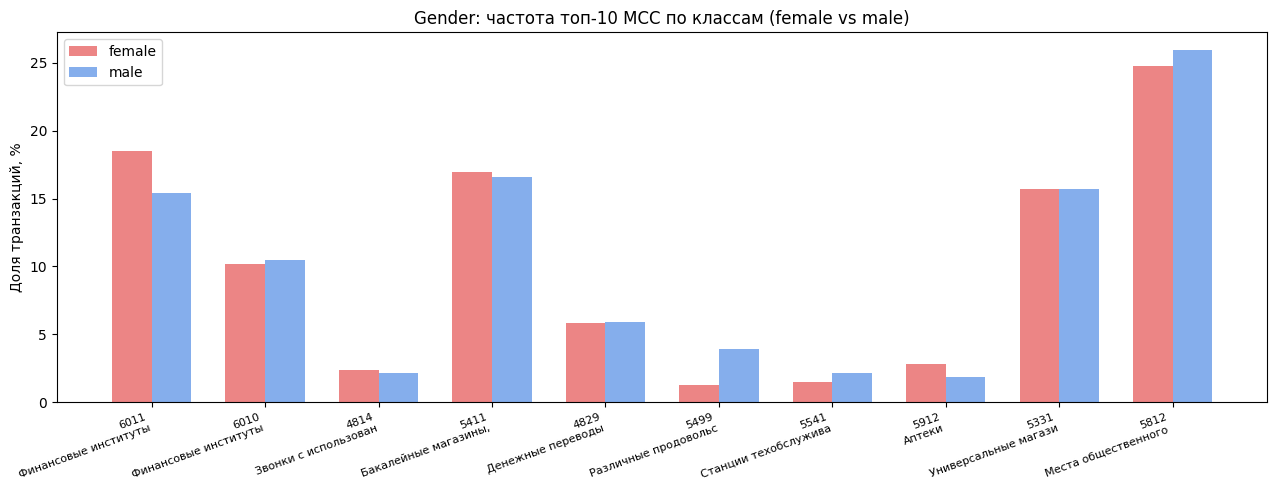

Сохранено: outputs/figures/eda/gender_class_differences.png


In [9]:
# Cell 9 — Различия между классами (gender=0 vs gender=1)
import matplotlib.pyplot as plt

txn_labeled = txn[txn[TARGET_COL].notna()].copy()
txn_labeled[TARGET_COL] = txn_labeled[TARGET_COL].astype(int)

# Для каждого гендера: частота использования каждого MCC (нормированная)
top10_mcc = txn[EVENT_TYPE_COL].value_counts().head(10).index.tolist()

freq_by_gender = (
    txn_labeled[txn_labeled[EVENT_TYPE_COL].isin(top10_mcc)]
    .groupby([TARGET_COL, EVENT_TYPE_COL])
    .size()
    .unstack(EVENT_TYPE_COL)
    .fillna(0)
)
# Нормируем по строкам (доля каждого MCC у каждого класса)
freq_norm = freq_by_gender.div(freq_by_gender.sum(axis=1), axis=0) * 100
freq_norm.index = freq_norm.index.map({0: "female", 1: "male"})

print("Доля (%) топ-10 MCC в транзакциях каждого гендера:")
display(freq_norm.round(2))

# Разница female - male
diff = freq_norm.loc["female"] - freq_norm.loc["male"]
print("\nРазница female - male (п.п.):")
print(diff.sort_values(ascending=False).round(3).to_string())

# Grouped bar chart
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(top10_mcc))
w = 0.35
ax.bar(x - w/2, freq_norm.loc["female"].values, w, label="female", color="#e97070", alpha=0.85)
ax.bar(x + w/2, freq_norm.loc["male"].values,   w, label="male",   color="#70a0e9", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{m}\n{mcc_ref_idx.get(m,'')[:20]}" for m in top10_mcc],
    fontsize=8, rotation=20, ha="right"
)
ax.set_ylabel("Доля транзакций, %")
ax.set_title("Gender: частота топ-10 MCC по классам (female vs male)")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/eda/gender_class_differences.png", dpi=150)
plt.show()
print("Сохранено: outputs/figures/eda/gender_class_differences.png")

Топ-15 переходов (from → to):


,from,from_desc,to,to_desc,count
0,6010,Финансовые институты — снятие наличности вручную,6010,Финансовые институты — снятие наличности вручную,621644
1,6011,Финансовые институты — снятие наличности автом...,6011,Финансовые институты — снятие наличности автом...,566451
2,4814,"Звонки с использованием телефонов, считывающих...",4814,"Звонки с использованием телефонов, считывающих...",368919
3,5411,"Бакалейные магазины, супермаркеты",5411,"Бакалейные магазины, супермаркеты",310866
4,4829,Денежные переводы,4829,Денежные переводы,227480
5,4814,"Звонки с использованием телефонов, считывающих...",6011,Финансовые институты — снятие наличности автом...,222363
6,6011,Финансовые институты — снятие наличности автом...,4814,"Звонки с использованием телефонов, считывающих...",218566
7,6011,Финансовые институты — снятие наличности автом...,5411,"Бакалейные магазины, супермаркеты",180059
8,5411,"Бакалейные магазины, супермаркеты",6011,Финансовые институты — снятие наличности автом...,177736
9,6010,Финансовые институты — снятие наличности вручную,4829,Денежные переводы,127105



Средняя энтропия строк (топ-20): 3.124 бит
Максимальная (равномерная):      4.322 бит
Вывод: переходы относительно равномерны — умеренная структура


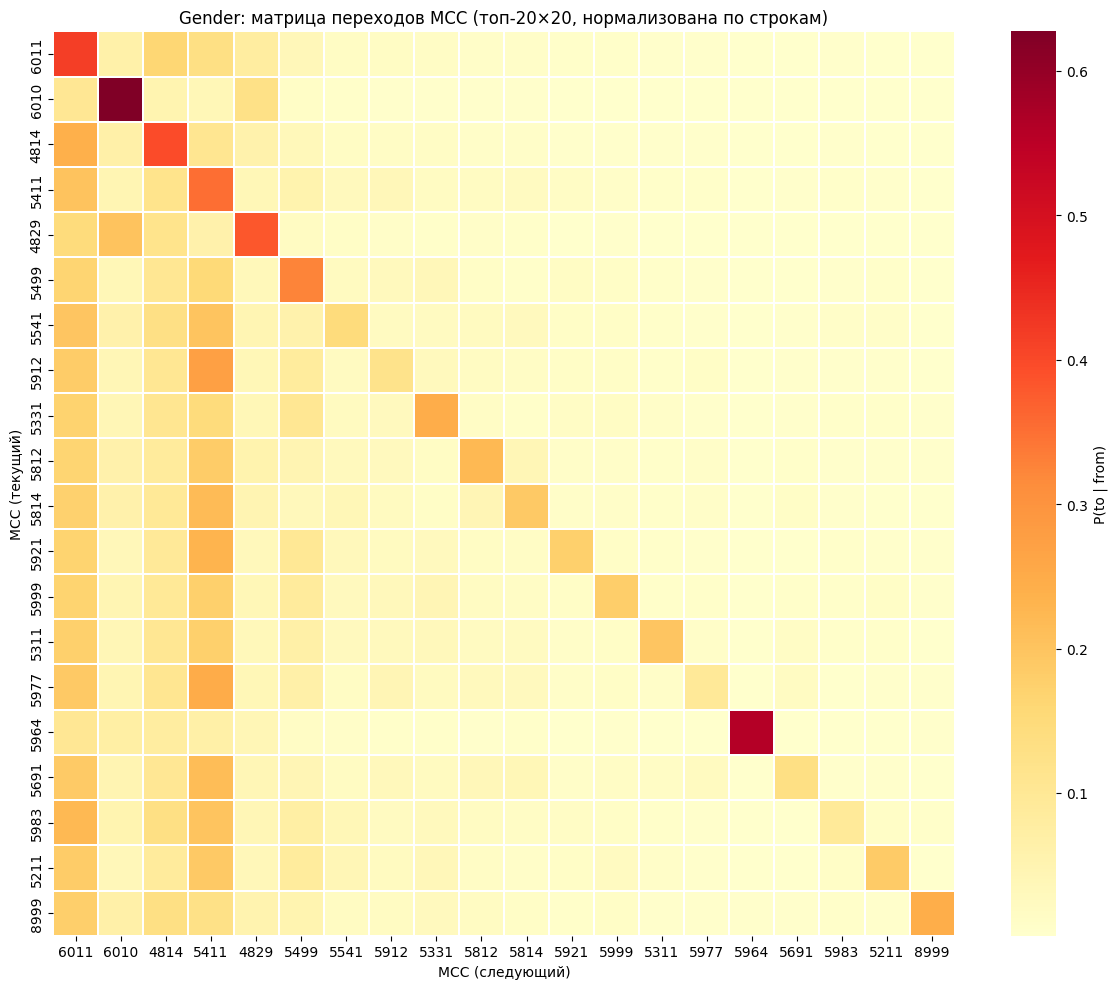

Сохранено: outputs/figures/eda/gender_transitions.png


In [10]:
# Cell 10 — Transition matrix
import seaborn as sns
from scipy.stats import entropy
from collections import Counter

txn_sorted2 = txn.sort_values([ENTITY_COL, TIMESTAMP_COL])
pairs = []
for _, grp in txn_sorted2.groupby(ENTITY_COL)[EVENT_TYPE_COL]:
    seq = grp.tolist()
    pairs.extend(zip(seq[:-1], seq[1:]))

pair_counts = Counter(pairs)
top15 = pair_counts.most_common(15)
print("Топ-15 переходов (from → to):")
top15_df = pd.DataFrame(top15, columns=["transition", "count"])
top15_df["from"]     = top15_df["transition"].apply(lambda x: x[0])
top15_df["to"]       = top15_df["transition"].apply(lambda x: x[1])
top15_df["from_desc"] = top15_df["from"].map(mcc_ref_idx).fillna("—")
top15_df["to_desc"]   = top15_df["to"].map(mcc_ref_idx).fillna("—")
display(top15_df[["from", "from_desc", "to", "to_desc", "count"]])

# Топ-20 MCC для heatmap
top20_mcc = txn[EVENT_TYPE_COL].value_counts().head(20).index.tolist()
mat = pd.DataFrame(0, index=top20_mcc, columns=top20_mcc, dtype=float)
for (a, b), cnt in pair_counts.items():
    if a in mat.index and b in mat.columns:
        mat.loc[a, b] += cnt

row_sums = mat.sum(axis=1).replace(0, 1)
mat_norm = mat.div(row_sums, axis=0)

row_entropies = mat_norm.apply(lambda row: entropy(row + 1e-12, base=2), axis=1)
mean_entropy  = row_entropies.mean()
max_entropy   = np.log2(len(top20_mcc))
print(f"\nСредняя энтропия строк (топ-20): {mean_entropy:.3f} бит")
print(f"Максимальная (равномерная):      {max_entropy:.3f} бит")
if mean_entropy < 0.5 * max_entropy:
    print("Вывод: переходы СТРУКТУРИРОВАНЫ → transition-aware replacement полезен")
else:
    print("Вывод: переходы относительно равномерны — умеренная структура")

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    mat_norm,
    cmap="YlOrRd", ax=ax, linewidths=0.3,
    cbar_kws={"label": "P(to | from)"},
    xticklabels=[str(x) for x in top20_mcc],
    yticklabels=[str(x) for x in top20_mcc],
)
ax.set_xlabel("MCC (следующий)")
ax.set_ylabel("MCC (текущий)")
ax.set_title("Gender: матрица переходов MCC (топ-20×20, нормализована по строкам)")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/gender_transitions.png", dpi=150)
plt.show()
print("Сохранено: outputs/figures/eda/gender_transitions.png")

In [11]:
# Cell 11 — Проверка качества
print("=== Проверка качества ===")

# Клиенты в transactions но отсутствуют и в train, и в submission
txn_ids   = set(txn[ENTITY_COL].unique())
train_ids = set(labels["customer_id"].unique())
test_ids  = set(subm["customer_id"].unique())
orphaned  = txn_ids - train_ids - test_ids
print(f"Клиентов в transactions, но нет в train/test: {len(orphaned):,}")

# Клиенты в train но без транзакций
train_no_txn = train_ids - txn_ids
print(f"Клиентов в gender_train без транзакций: {len(train_no_txn):,}")

# Покрытие test в transactions
test_no_txn = test_ids - txn_ids
print(f"Клиентов в submission без транзакций:   {len(test_no_txn):,}")

# Дубликаты транзакций
dup = txn.duplicated(subset=[ENTITY_COL, "tr_datetime"]).sum()
print(f"\nДубликаты (customer_id, tr_datetime): {dup:,}")

# Аномалии timestamp
ts = txn[TIMESTAMP_COL]
before_2000 = (ts.dt.year < 2000).sum()
future       = (ts.dt.year > 2026).sum()
print(f"\nТранзакции до 2000:   {before_2000:,}")
print(f"Транзакции после 2026:{future:,}")
print(f"Диапазон дат: {ts.min().date()} — {ts.max().date()}")

# NaN в ключевых полях
print("\nПропуски в ключевых полях:")
for col in [ENTITY_COL, TIMESTAMP_COL, EVENT_TYPE_COL]:
    n = txn[col].isna().sum()
    print(f"  {col}: {n:,}")

# term_id — насколько заполнен
term_fill = txn["term_id"].notna().mean() * 100
print(f"\nЗаполненность term_id: {term_fill:.1f}% (если < 50% — исключить из CAT_COLS)")

=== Проверка качества ===
Клиентов в transactions, но нет в train/test: 3,000
Клиентов в gender_train без транзакций: 0
Клиентов в submission без транзакций:   0



Дубликаты (customer_id, tr_datetime): 279,403



Транзакции до 2000:   0
Транзакции после 2026:0
Диапазон дат: 2010-01-01 — 2011-04-02

Пропуски в ключевых полях:
  customer_id: 0
  timestamp: 0
  mcc_code: 0



Заполненность term_id: 59.6% (если < 50% — исключить из CAT_COLS)


In [12]:
# Cell 12 — Итоги и сохранение
import json

txn_counts_f = txn.groupby(ENTITY_COL).size()
pcts_f = txn_counts_f.quantile([0.95, 0.99])
max_seq_rec = int(pcts_f[0.95])

cg = txn.groupby(ENTITY_COL)[TARGET_COL].first().dropna()
vc_f = cg.value_counts()
imb_f = float(vc_f.max() / vc_f.min())

td_vals_f = (
    txn.sort_values([ENTITY_COL, TIMESTAMP_COL])
    .groupby(ENTITY_COL)[TIMESTAMP_COL].diff()
    .dt.total_seconds().dropna()
)
use_log1p = bool(td_vals_f[td_vals_f > 0].mean() > 3 * td_vals_f[td_vals_f > 0].median())

amt = txn["amount"]
pct_neg_f = float((amt < 0).mean() * 100)
if pct_neg_f > 1:
    rec_scaler = "sign*log1p"
elif abs(amt.skew()) > 2:
    rec_scaler = "RobustScaler"
else:
    rec_scaler = "StandardScaler"

# Transition-aware
top20_f = txn[EVENT_TYPE_COL].value_counts().head(20).index.tolist()
mat_f = pd.DataFrame(0, index=top20_f, columns=top20_f, dtype=float)
for (a, b), cnt in pair_counts.items():
    if a in mat_f.index and b in mat_f.columns:
        mat_f.loc[a, b] += cnt
rs_f = mat_f.sum(axis=1).replace(0, 1)
mn_f = mat_f.div(rs_f, axis=0)
me_f = mn_f.apply(lambda r: entropy(r + 1e-12, base=2), axis=1).mean()
transition_useful = bool(me_f < 0.5 * np.log2(20))

recs = {
    "max_seq_len":             max_seq_rec,
    "min_seq_len":             2,
    "vocab_size_mcc":          int(txn[EVENT_TYPE_COL].nunique()),
    "vocab_size_tr_type":      int(txn["tr_type"].nunique()),
    "class_imbalance_ratio":   round(imb_f, 4),
    "use_log1p_time":          use_log1p,
    "recommended_scaler":      rec_scaler,
    "amount_has_negatives_pct": round(pct_neg_f, 2),
    "transition_aware_useful": transition_useful,
    "n_train_clients":         int(len(train_ids)),
    "n_test_clients":          int(len(test_ids)),
    "n_total_txn":             int(len(txn)),
    "mean_seq_len":            round(float(txn_counts_f.mean()), 2),
    "median_seq_len":          int(txn_counts_f.median()),
    "p90_seq_len":             int(txn_counts_f.quantile(0.90)),
    "p95_seq_len":             int(pcts_f[0.95]),
    "p99_seq_len":             int(pcts_f[0.99]),
    "mean_entropy_transitions": round(float(me_f), 4),
    "term_id_fill_pct":         round(float(txn["term_id"].notna().mean() * 100), 2),
}

print("=== Итоговые рекомендации ===")
display(pd.Series(recs).to_frame("value"))

out_path = "../outputs/metrics/eda_gender.json"
with open(out_path, "w") as f:
    json.dump(recs, f, indent=2)
print(f"\nСохранено: {out_path}")
print("Gender EDA complete.")

=== Итоговые рекомендации ===


,value
max_seq_len,1089
min_seq_len,2
vocab_size_mcc,184
vocab_size_tr_type,77
class_imbalance_ratio,1.2623
use_log1p_time,True
recommended_scaler,sign*log1p
amount_has_negatives_pct,80.91
transition_aware_useful,False
n_train_clients,8400



Сохранено: ../outputs/metrics/eda_gender.json
Gender EDA complete.
